# Analisis Pola Pembelian dengan Algoritma Apriori (Association Rule Mining)

1. Import Library

In [2]:
# Import library dasar untuk manipulasi data dan komputasi numerik
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt

# Import modul bawaan Python (built-in, tidak perlu instalasi)
from itertools import combinations   
from collections import Counter     

# Pengaturan tampilan agar output lebih rapi
pd.set_option('display.max_colwidth', 100)

print("Semua library berhasil diimport")


Semua library berhasil diimport


2. Load Dataset

In [3]:
# Membaca dataset CSV.
# header=None  -> karena file ini tidak memiliki baris judul kolom,
#                  baris pertama pada file adalah data transaksi, bukan header.
df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)

# Menampilkan 5 baris pertama untuk memastikan data terbaca dengan benar
df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


3. Eksplorasi Dataset

In [4]:
# Melihat ukuran dataset (jumlah baris/transaksi dan jumlah kolom)
print("Shape dataset (baris, kolom):", df.shape)
print(f"Jumlah transaksi : {df.shape[0]}")
print(f"Jumlah kolom (slot produk maksimum per transaksi) : {df.shape[1]}")

# Melihat 5 baris pertama dataset
df.head()


Shape dataset (baris, kolom): (7501, 20)
Jumlah transaksi : 7501
Jumlah kolom (slot produk maksimum per transaksi) : 20


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Informasi umum mengenai dataset: tipe data setiap kolom dan jumlah nilai non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [6]:
# Mengecek jumlah missing value (NaN) pada setiap kolom
missing = df.isnull().sum()
print("Jumlah missing value per kolom:")
print(missing)
print("\nTotal missing value pada seluruh dataset:", missing.sum())

# Menghitung jumlah transaksi (baris) dalam dataset
jumlah_transaksi = df.shape[0]
print(f"\nJumlah total transaksi dalam dataset: {jumlah_transaksi} transaksi")


Jumlah missing value per kolom:
0        0
1     1754
2     3112
3     4156
4     4972
5     5637
6     6132
7     6520
8     6847
9     7106
10    7245
11    7347
12    7414
13    7454
14    7476
15    7493
16    7497
17    7497
18    7498
19    7500
dtype: int64

Total missing value pada seluruh dataset: 120657

Jumlah total transaksi dalam dataset: 7501 transaksi


4. Preprocessing Data — Mengubah Baris Menjadi List Transaksi


In [7]:
# Membuat list transaksi: setiap baris diubah menjadi list produk tanpa nilai NaN
transactions = []

for i in range(len(df)):
    # Mengambil satu baris (transaksi), buang nilai NaN, lalu ubah jadi list
    transaksi_i = df.iloc[i].dropna().tolist()
    transactions.append(transaksi_i)

# Menampilkan contoh 3 transaksi pertama hasil preprocessing
print("Jumlah total transaksi setelah preprocessing:", len(transactions))
print("\nContoh 3 transaksi pertama:")
for t in transactions[:3]:
    print(t)


Jumlah total transaksi setelah preprocessing: 7501

Contoh 3 transaksi pertama:
['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
['burgers', 'meatballs', 'eggs']
['chutney']


In [8]:
# Mengubah setiap transaksi (list) menjadi set, agar pengecekan keanggotaan/subset lebih cepat
transactions_set = [set(transaksi) for transaksi in transactions]

# Menghitung total jumlah transaksi (digunakan untuk menghitung support nanti)
total_transaksi = len(transactions_set)

print("Contoh transaksi pertama dalam bentuk set:", transactions_set[0])
print("Total transaksi:", total_transaksi)


Contoh transaksi pertama dalam bentuk set: {'whole weat flour', 'olive oil', 'tomato juice', 'salad', 'antioxydant juice', 'vegetables mix', 'mineral water', 'honey', 'frozen smoothie', 'energy drink', 'avocado', 'salmon', 'spinach', 'almonds', 'yams', 'green tea', 'cottage cheese', 'shrimp', 'low fat yogurt', 'green grapes'}
Total transaksi: 7501


5. One-Hot Encoding Secara Manual


In [ ]:
# Langkah 1: Mengumpulkan seluruh nama produk unik dari seluruh transaksi
semua_produk_unik = sorted(set(item for transaksi in transactions for item in transaksi))
print(f"Jumlah produk unik yang teridentifikasi: {len(semua_produk_unik)}")

# Langkah 2 & 3: Membuat baris one-hot encoding untuk setiap transaksi secara manual
data_encoded = []
for t_set in transactions_set:
    # Untuk setiap produk unik, beri nilai 1 jika ada di transaksi, 0 jika tidak
    baris = [1 if produk in t_set else 0 for produk in semua_produk_unik]
    data_encoded.append(baris)

# Menggabungkan menjadi DataFrame, dengan nama kolom = nama produk
df_encoded = pd.DataFrame(data_encoded, columns=semua_produk_unik)

print("Ukuran data hasil encoding:", df_encoded.shape)


Jumlah produk unik yang teridentifikasi: 120
Ukuran data hasil encoding: (7501, 120)
[' asparagus', 'almonds', 'antioxydant juice', 'asparagus', 'avocado', 'babies food', 'bacon', 'barbecue sauce', 'black tea', 'blueberries', 'body spray', 'bramble', 'brownies', 'bug spray', 'burger sauce', 'burgers', 'butter', 'cake', 'candy bars', 'carrots', 'cauliflower', 'cereals', 'champagne', 'chicken', 'chili', 'chocolate', 'chocolate bread', 'chutney', 'cider', 'clothes accessories', 'cookies', 'cooking oil', 'corn', 'cottage cheese', 'cream', 'dessert wine', 'eggplant', 'eggs', 'energy bar', 'energy drink', 'escalope', 'extra dark chocolate', 'flax seed', 'french fries', 'french wine', 'fresh bread', 'fresh tuna', 'fromage blanc', 'frozen smoothie', 'frozen vegetables', 'gluten free bar', 'grated cheese', 'green beans', 'green grapes', 'green tea', 'ground beef', 'gums', 'ham', 'hand protein bar', 'herb & pepper', 'honey', 'hot dogs', 'ketchup', 'light cream', 'light mayo', 'low fat yogurt', '

6. Menampilkan Data Hasil Encoding


In [10]:
# Menampilkan 5 baris pertama data hasil one-hot encoding
df_encoded.head()


,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,0,1,1,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


7. Implementasi Manual Algoritma Apriori

Algoritma **Apriori** digunakan untuk mencari **frequent itemsets**, yaitu kombinasi produk (1 produk, 2 produk, atau lebih) yang sering muncul bersamaan dalam transaksi, berdasarkan nilai **support** minimum yang ditentukan.

Konsep Dasar: Support

$$ \text{support}(A) = \frac{\text{jumlah transaksi yang mengandung itemset } A}{\text{jumlah seluruh transaksi}} $$

`min_support` adalah ambang batas minimum nilai support agar suatu itemset dianggap "sering muncul" (*frequent*). Pada notebook ini digunakan **`min_support = 0.02`**, artinya hanya itemset yang muncul pada **minimal 2% dari seluruh transaksi** (sekitar 150 dari 7.501 transaksi) yang akan dipertimbangkan.


In [ ]:
def hitung_support(itemset, transactions_set, total_transaksi):
    itemset = set(itemset)
    jumlah_muncul = sum(1 for transaksi in transactions_set if itemset.issubset(transaksi))
    return jumlah_muncul / total_transaksi


In [ ]:
def apriori_manual(transactions, transactions_set, total_transaksi, min_support):
    # Langkah 1: Kandidat awal -> seluruh produk unik sebagai itemset berukuran 1
    semua_item = set(item for transaksi in transactions for item in transaksi)
    kandidat_saat_ini = [frozenset([item]) for item in semua_item]

    frequent_itemsets_dict = {}   # menyimpan SELURUH frequent itemset dari semua level
    ukuran_itemset = 1

    while kandidat_saat_ini:
        # Langkah 2: Support Counting -> hitung support setiap kandidat pada level ini
        support_level_ini = {}
        for kandidat in kandidat_saat_ini:
            nilai_support = hitung_support(kandidat, transactions_set, total_transaksi)
            # Langkah 3: Pruning -> hanya simpan kandidat dengan support >= min_support
            if nilai_support >= min_support:
                support_level_ini[kandidat] = nilai_support

        # Jika tidak ada kandidat yang lolos, hentikan iterasi
        if not support_level_ini:
            break

        # Simpan seluruh frequent itemset level ini ke dalam hasil akhir
        frequent_itemsets_dict.update(support_level_ini)

        # Langkah 4: Candidate Generation -> gabungkan pasangan itemset level ini
        # untuk membentuk kandidat level (k+1)
        daftar_frequent = list(support_level_ini.keys())
        kandidat_berikutnya = set()
        for i in range(len(daftar_frequent)):
            for j in range(i + 1, len(daftar_frequent)):
                gabungan = daftar_frequent[i] | daftar_frequent[j]
                if len(gabungan) == ukuran_itemset + 1:
                    kandidat_berikutnya.add(gabungan)

        # Langkah 5: Apriori Property -> kandidat hanya valid jika SEMUA subset
        # berukuran k dari kandidat tersebut juga frequent pada level sebelumnya
        kandidat_tervalidasi = []
        for kandidat in kandidat_berikutnya:
            subset_k = combinations(kandidat, len(kandidat) - 1)
            if all(frozenset(s) in support_level_ini for s in subset_k):
                kandidat_tervalidasi.append(kandidat)

        kandidat_saat_ini = kandidat_tervalidasi
        ukuran_itemset += 1

        print(f"Level {ukuran_itemset - 1}: {len(support_level_ini)} frequent itemset "
              f"ditemukan, {len(kandidat_tervalidasi)} kandidat untuk level berikutnya.")

    return frequent_itemsets_dict


In [13]:
# Menjalankan algoritma Apriori manual dengan min_support = 0.02
# Artinya: hanya itemset yang muncul di minimal 2% transaksi yang dianggap "frequent"
min_support = 0.02
support_dict = apriori_manual(transactions, transactions_set, total_transaksi, min_support)

print(f"\nTotal frequent itemsets yang ditemukan: {len(support_dict)}")


Level 1: 53 frequent itemset ditemukan, 1378 kandidat untuk level berikutnya.
Level 2: 50 frequent itemset ditemukan, 61 kandidat untuk level berikutnya.

Total frequent itemsets yang ditemukan: 103


8. Menampilkan Frequent Itemsets


In [14]:
# Mengubah hasil frequent itemsets (dictionary) menjadi DataFrame agar mudah ditampilkan
frequent_itemsets = pd.DataFrame([
    {'itemsets': itemset, 'support': supp, 'length': len(itemset)}
    for itemset, supp in support_dict.items()
])

# Menampilkan frequent itemsets, diurutkan berdasarkan nilai support tertinggi
frequent_itemsets.sort_values(by='support', ascending=False).head(15)


,itemsets,support,length
6,(mineral water),0.238368,1
28,(eggs),0.179709,1
11,(spaghetti),0.174110,1
9,(french fries),0.170911,1
48,(chocolate),0.163845,1
12,(green tea),0.132116,1
47,(milk),0.129583,1
17,(ground beef),0.098254,1
27,(frozen vegetables),0.095321,1
0,(pancakes),0.095054,1


9. Membentuk Association Rules Secara Manual

Setelah mendapatkan frequent itemsets, langkah selanjutnya adalah membentuk **aturan asosiasi (association rules)** dalam bentuk:

> Jika **antecedent** (produk A) dibeli, maka **consequent** (produk B) juga cenderung dibeli.

### Rumus yang Digunakan

- **Confidence** — metrik utama yang digunakan untuk menyaring aturan, menunjukkan seberapa besar kemungkinan produk B dibeli **jika** produk A sudah dibeli:

  $$ \text{confidence}(A \rightarrow B) = \frac{\text{support}(A \cup B)}{\text{support}(A)} $$

- **Lift** — menunjukkan seberapa kuat hubungan antara A dan B dibandingkan jika keduanya independen:

  $$ \text{lift}(A \rightarrow B) = \frac{\text{confidence}(A \rightarrow B)}{\text{support}(B)} $$



In [15]:
def buat_rules_manual(support_dict, min_confidence):
    daftar_rules = []

    for itemset in support_dict:
        # Aturan hanya bisa dibentuk dari itemset berisi minimal 2 produk
        if len(itemset) < 2:
            continue

        items = list(itemset)
        # Membentuk seluruh kemungkinan antecedent (subset tak kosong dan bukan itemset penuh)
        for ukuran_antecedent in range(1, len(items)):
            for antecedent_tuple in combinations(items, ukuran_antecedent):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                support_itemset = support_dict[itemset]          # support(A union B)
                support_antecedent = support_dict[antecedent]    # support(A)
                support_consequent = support_dict[consequent]    # support(B)

                # Rumus confidence dan lift
                confidence = support_itemset / support_antecedent
                lift = confidence / support_consequent

                # Hanya simpan aturan yang memenuhi ambang batas confidence
                if confidence >= min_confidence:
                    daftar_rules.append({
                        'antecedents': antecedent,
                        'consequents': consequent,
                        'support': support_itemset,
                        'confidence': confidence,
                        'lift': lift
                    })

    return pd.DataFrame(daftar_rules)


In [16]:
# Membentuk association rules dari frequent itemsets
# metric yang digunakan untuk menyaring aturan adalah CONFIDENCE
# min_confidence=0.2 -> hanya aturan dengan confidence minimal 20% yang ditampilkan
min_confidence = 0.2
rules = buat_rules_manual(support_dict, min_confidence)

print(f"Jumlah association rules yang terbentuk: {len(rules)}")


Jumlah association rules yang terbentuk: 55


10. Menampilkan Hasil Association Rules

Kolom-kolom utama yang ditampilkan:
- **antecedents** : produk (atau kombinasi produk) yang menjadi "pemicu" / kondisi awal.
- **consequents** : produk yang cenderung dibeli setelah antecedent dibeli.
- **support** : proporsi transaksi yang mengandung kedua itemset (antecedent + consequent) sekaligus.
- **confidence** : tingkat keyakinan/kemungkinan aturan tersebut benar.
- **lift** : seberapa kuat hubungan antara antecedent dan consequent dibandingkan jika keduanya bersifat independen (lift > 1 berarti hubungan positif/saling memperkuat).


In [17]:
# Menampilkan kolom-kolom utama dari hasil association rules
rules_tampil = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_tampil.head(15)


,antecedents,consequents,support,confidence,lift
0,(mineral water),(eggs),0.050927,0.213647,1.188845
1,(eggs),(mineral water),0.050927,0.283383,1.188845
2,(shrimp),(mineral water),0.023597,0.330224,1.385352
3,(frozen vegetables),(eggs),0.021730,0.227972,1.268559
4,(burgers),(spaghetti),0.021464,0.246177,1.413918
5,(spaghetti),(milk),0.035462,0.203675,1.571779
6,(milk),(spaghetti),0.035462,0.273663,1.571779
7,(green tea),(mineral water),0.031063,0.235116,0.986357
8,(burgers),(french fries),0.021997,0.252294,1.476173
9,(spaghetti),(ground beef),0.039195,0.225115,2.291162


11. Mengurutkan Aturan Berdasarkan Nilai Lift Tertinggi


In [18]:
# Mengurutkan rules berdasarkan nilai lift dari yang tertinggi ke terendah
rules_sorted = rules.sort_values(by='lift', ascending=False)

# Menampilkan 10 aturan dengan lift tertinggi
top10_lift = rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
top10_lift


,antecedents,consequents,support,confidence,lift
9,(spaghetti),(ground beef),0.039195,0.225115,2.291162
10,(ground beef),(spaghetti),0.039195,0.398915,2.291162
54,(olive oil),(spaghetti),0.022930,0.348178,1.999758
14,(soup),(mineral water),0.023064,0.456464,1.914955
15,(frozen vegetables),(milk),0.023597,0.247552,1.910382
40,(burgers),(eggs),0.028796,0.330275,1.837830
39,(olive oil),(mineral water),0.027596,0.419028,1.757904
24,(tomatoes),(spaghetti),0.020931,0.306043,1.757755
23,(ground beef),(mineral water),0.040928,0.416554,1.747522
33,(ground beef),(milk),0.021997,0.223881,1.727704


12. Visualisasi Hasil Analisis

12.1 Top 10 Produk yang Paling Sering Muncul

Visualisasi ini menghitung frekuensi kemunculan setiap produk pada **seluruh transaksi mentah** (sebelum proses Apriori), untuk melihat produk apa saja yang paling populer secara umum.


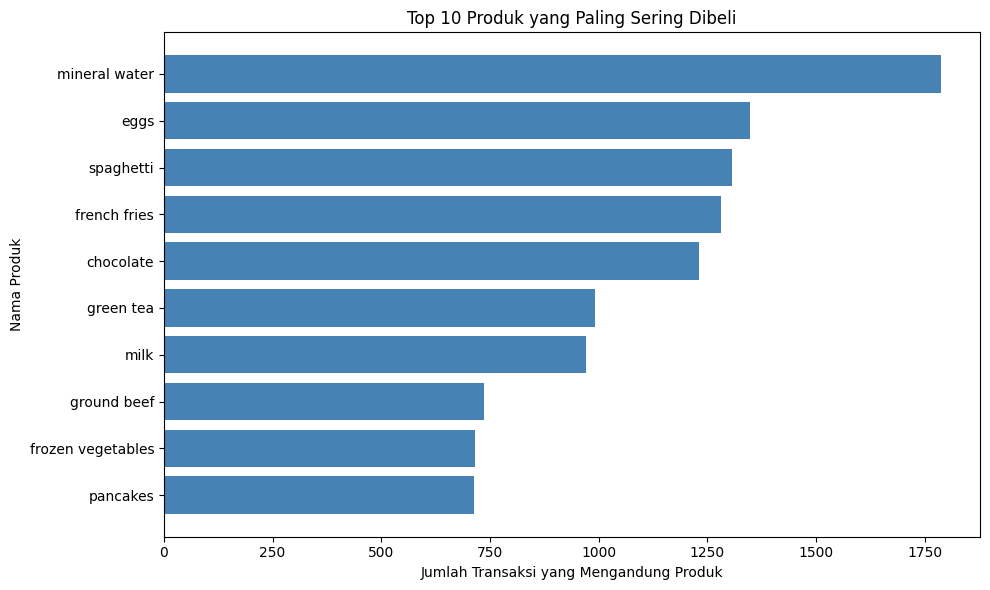

In [19]:
# Menghitung frekuensi kemunculan setiap produk di seluruh transaksi
semua_produk = [item for transaksi in transactions for item in transaksi]
frekuensi_produk = Counter(semua_produk)

# Mengambil 10 produk dengan frekuensi tertinggi
top10_produk = pd.Series(frekuensi_produk).sort_values(ascending=False).head(10)

# Membuat bar chart top 10 produk
plt.figure(figsize=(10, 6))
plt.barh(top10_produk.index[::-1], top10_produk.values[::-1], color='steelblue')
plt.xlabel('Jumlah Transaksi yang Mengandung Produk')
plt.ylabel('Nama Produk')
plt.title('Top 10 Produk yang Paling Sering Dibeli')
plt.tight_layout()
plt.show()


12.2 Top 10 Frequent Itemsets Berdasarkan Support

Visualisasi ini menampilkan 10 itemset (baik tunggal maupun kombinasi produk) dengan nilai **support** tertinggi hasil algoritma Apriori manual.


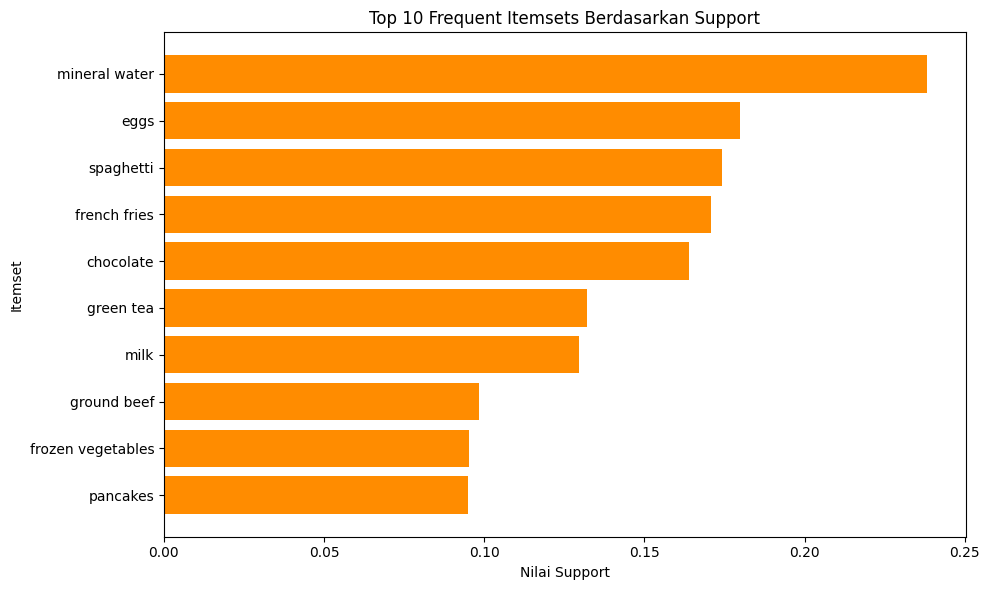

In [20]:
# Mengambil 10 frequent itemsets dengan support tertinggi
top10_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10).copy()

# Mengubah format itemsets (frozenset) menjadi string agar mudah ditampilkan di label grafik
top10_itemsets['itemsets_str'] = top10_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

# Membuat bar chart top 10 frequent itemsets
plt.figure(figsize=(10, 6))
plt.barh(top10_itemsets['itemsets_str'][::-1], top10_itemsets['support'][::-1], color='darkorange')
plt.xlabel('Nilai Support')
plt.ylabel('Itemset')
plt.title('Top 10 Frequent Itemsets Berdasarkan Support')
plt.tight_layout()
plt.show()


12.3 Scatter Plot Support vs Confidence

Visualisasi ini membantu melihat distribusi seluruh association rules berdasarkan dua metrik sekaligus: support dan confidence, dengan warna merepresentasikan nilai lift.


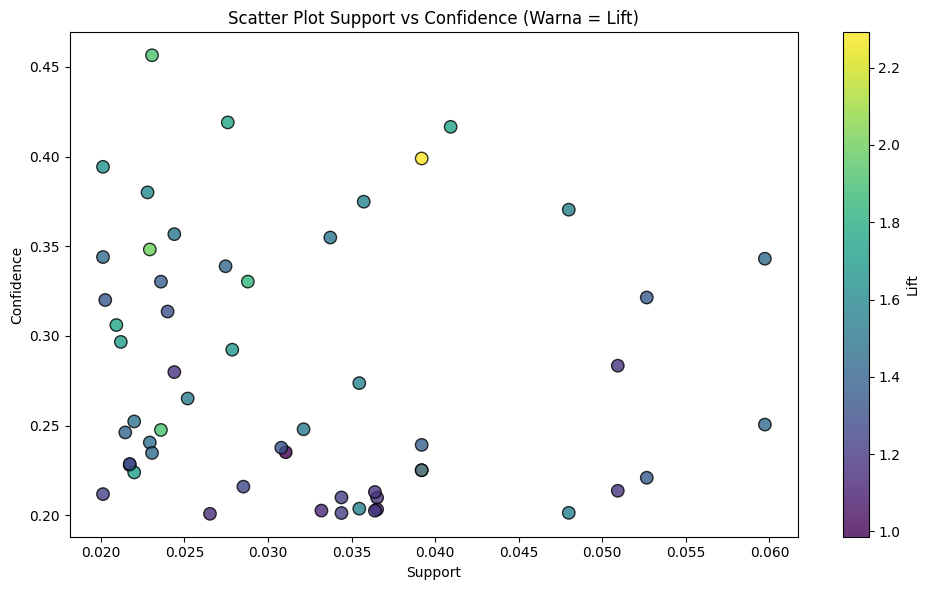

In [21]:
# Membuat scatter plot Support vs Confidence
# Warna titik merepresentasikan nilai lift (semakin terang/kuning = lift semakin tinggi)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rules['support'], rules['confidence'],
                       c=rules['lift'], cmap='viridis', s=80, edgecolor='black', alpha=0.8)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Scatter Plot Support vs Confidence (Warna = Lift)')
plt.tight_layout()
plt.show()


12.4 Bar Chart Top 10 Rules Berdasarkan Lift

Visualisasi ini menampilkan 10 aturan asosiasi dengan nilai **lift** tertinggi, yang merepresentasikan hubungan antar produk paling kuat dalam dataset.


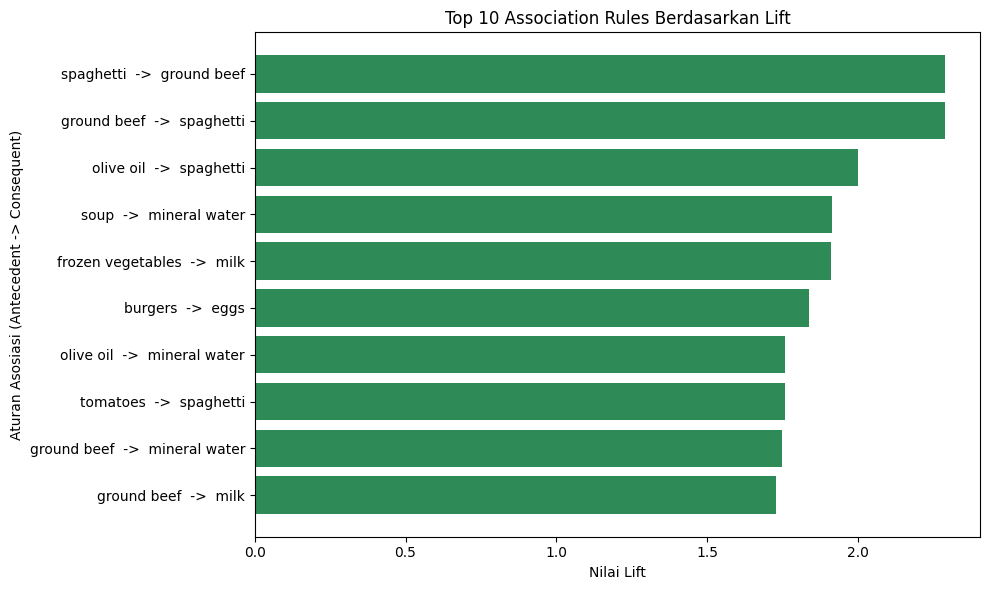

In [22]:
# Menyiapkan label aturan (antecedent -> consequent) dalam bentuk teks untuk top 10 rules berdasarkan lift
top10_rules = rules_sorted.head(10).copy()
top10_rules['rule_label'] = top10_rules.apply(
    lambda row: ', '.join(list(row['antecedents'])) + '  ->  ' + ', '.join(list(row['consequents'])),
    axis=1
)

# Membuat bar chart top 10 rules berdasarkan lift
plt.figure(figsize=(10, 6))
plt.barh(top10_rules['rule_label'][::-1], top10_rules['lift'][::-1], color='seagreen')
plt.xlabel('Nilai Lift')
plt.ylabel('Aturan Asosiasi (Antecedent -> Consequent)')
plt.title('Top 10 Association Rules Berdasarkan Lift')
plt.tight_layout()
plt.show()


13. Analisis Tambahan — Bukti Empiris Efisiensi Algoritma Apriori


In [ ]:
import time

print("Menjalankan ulang Apriori untuk mengukur waktu eksekusi...")
start = time.time()
support_dict_timed = apriori_manual(transactions, transactions_set, total_transaksi, min_support)
end = time.time()

waktu_eksekusi = end - start
print(f"\nWaktu eksekusi algoritma Apriori manual : {waktu_eksekusi:.2f} detik")
print(f"Jumlah frequent itemsets yang ditemukan : {len(support_dict_timed)}")
print(f"\nCatatan: Waktu ini mencakup seluruh siklus candidate generation,")
print(f"support counting, pruning, dan validasi Apriori Property.")


Menjalankan ulang Apriori untuk mengukur waktu eksekusi...
Level 1: 53 frequent itemset ditemukan, 1378 kandidat untuk level berikutnya.
Level 2: 50 frequent itemset ditemukan, 61 kandidat untuk level berikutnya.

Waktu eksekusi algoritma Apriori manual : 3.02 detik
Jumlah frequent itemsets yang ditemukan : 103

Catatan: Waktu ini mencakup seluruh siklus candidate generation,
support counting, pruning, dan validasi Apriori Property.


In [ ]:
# TAMBAHAN 2 — Perbandingan Jumlah Kandidat: Apriori vs. Brute-force
from math import comb

# Jumlah produk unik dalam dataset
n_produk = len(set(item for transaksi in transactions for item in transaksi))

# Brute-force: harus mengecek SEMUA kombinasi ukuran 1, 2, dan 3 dari seluruh produk
# (level 3 tidak ada frequent itemset-nya, tapi brute-force tetap harus cek semua)
brute_level1 = comb(n_produk, 1)  # = n_produk
brute_level2 = comb(n_produk, 2)
brute_level3 = comb(n_produk, 3)
total_brute = brute_level1 + brute_level2 + brute_level3

# Apriori: kandidat yang benar-benar dievaluasi (dari output run sebelumnya)
# Level 1: 120, Level 2: 1378 kandidat (dari 53 frequent L1), Level 3: 61 kandidat (dari 50 frequent L2)
apriori_level1 = n_produk        # seluruh produk unik jadi kandidat level 1
apriori_level2 = 1378            # jumlah kandidat level 2 (output dari apriori_manual di atas)
apriori_level3 = 61              # jumlah kandidat level 3
total_apriori = apriori_level1 + apriori_level2 + apriori_level3

print("=" * 60)
print(f"Jumlah produk unik : {n_produk}")
print("=" * 60)
print(f"{'Pendekatan':<30} {'Level 1':>8} {'Level 2':>10} {'Level 3':>10} {'Total':>10}")
print("-" * 60)
print(f"{'Brute-force (tanpa pruning)':<30} {brute_level1:>8,} {brute_level2:>10,} {brute_level3:>10,} {total_brute:>10,}")
print(f"{'Apriori manual (dengan pruning)':<30} {apriori_level1:>8,} {apriori_level2:>10,} {apriori_level3:>10,} {total_apriori:>10,}")
print("=" * 60)
print(f"Pengurangan kandidat yang dievaluasi : {(1 - total_apriori/total_brute)*100:.1f}%")
print()
print("Interpretasi:")
print(f"Tanpa pruning, brute-force harus mengevaluasi {total_brute:,} kombinasi.")
print(f"Dengan Apriori Property, hanya {total_apriori:,} kandidat yang perlu dievaluasi.")
print(f"Ini menunjukkan penghematan komputasi lebih dari {(1 - total_apriori/total_brute)*100:.0f}% —")
print(f"bukti empiris bahwa pruning Apriori Property bekerja sangat efektif.")


Jumlah produk unik : 120
Pendekatan                      Level 1    Level 2    Level 3      Total
------------------------------------------------------------
Brute-force (tanpa pruning)         120      7,140    280,840    288,100
Apriori manual (dengan pruning)      120      1,378         61      1,559
Pengurangan kandidat yang dievaluasi : 99.5%

Interpretasi:
Tanpa pruning, brute-force harus mengevaluasi 288,100 kombinasi.
Dengan Apriori Property, hanya 1,559 kandidat yang perlu dievaluasi.
Ini menunjukkan penghematan komputasi lebih dari 99% —
bukti empiris bahwa pruning Apriori Property bekerja sangat efektif.


In [25]:
# ============================================================
# TAMBAHAN 3 — Sanity-check: Validasi Implementasi Manual
# ============================================================
# Menghitung ulang support 'mineral water' langsung dari data (tanpa fungsi hitung_support)
# lalu membandingkan dengan nilai yang tersimpan di support_dict

# Hitung langsung (manual, tanpa fungsi)
item_cek = 'mineral water'
manual_count = sum(1 for t in transactions_set if item_cek in t)
manual_support = manual_count / total_transaksi

# Ambil dari support_dict hasil apriori_manual
support_dari_dict = support_dict[frozenset([item_cek])]

print("=" * 55)
print(f"Validasi nilai support untuk item: '{item_cek}'")
print("=" * 55)
print(f"Perhitungan langsung dari data  : {manual_support:.6f}")
print(f"Nilai dari support_dict         : {support_dari_dict:.6f}")
print(f"Selisih (delta)                 : {abs(manual_support - support_dari_dict):.10f}")
print()
if abs(manual_support - support_dari_dict) < 1e-9:
    print("✓ VALIDASI BERHASIL: Implementasi fungsi hitung_support() menghasilkan")
    print("  nilai yang identik dengan perhitungan langsung dari data.")
else:
    print("✗ PERHATIAN: Ada perbedaan nilai — perlu dicek ulang.")

# Verifikasi tambahan: cek 3 produk lain secara sekaligus
print()
print("Verifikasi tambahan untuk beberapa produk lain:")
for item_test in ['eggs', 'spaghetti', 'chocolate']:
    manual = sum(1 for t in transactions_set if item_test in t) / total_transaksi
    dari_dict = support_dict[frozenset([item_test])]
    status = '✓' if abs(manual - dari_dict) < 1e-9 else '✗'
    print(f"  {status} '{item_test}': manual={manual:.6f}, dict={dari_dict:.6f}")


Validasi nilai support untuk item: 'mineral water'
Perhitungan langsung dari data  : 0.238368
Nilai dari support_dict         : 0.238368
Selisih (delta)                 : 0.0000000000

✓ VALIDASI BERHASIL: Implementasi fungsi hitung_support() menghasilkan
  nilai yang identik dengan perhitungan langsung dari data.

Verifikasi tambahan untuk beberapa produk lain:
  ✓ 'eggs': manual=0.179709, dict=0.179709
  ✓ 'spaghetti': manual=0.174110, dict=0.174110
  ✓ 'chocolate': manual=0.163845, dict=0.163845
